# Regresión Lineal Múltiple — Ventas Walmart

**¿Qué es la Regresión Lineal Múltiple (RLM)?**  
Busca una relación **lineal** entre varias variables de entrada y una variable a predecir.

```
ventas = w1·Holiday + w2·Temp + w3·CPI + w4·Store_2 + w5·Store_3 + ... + b
```

**Dataset:** Walmart.csv — 6,435 registros, 45 tiendas  
**Variable objetivo (Y):** `Weekly_Sales` (ventas semanales en USD)

---
### Decisiones de preprocesamiento

| Columna | Tratamiento | ¿Por qué? |
|---|---|---|
| `Date` | Se descarta | No aporta directamente como número |
| `Store` | **One-Hot Encoding** (`get_dummies`) | Es una categoría, no un número continuo |
| `Holiday_Flag` | Se usa directo (ya es 0/1) | Ya es binario |
| Numéricas | `StandardScaler` | Lleva todo a media=0, std=1 |

**¿Por qué `get_dummies` en Store y no dejarlo como número 1–45?**  
Si dejamos Store como número, el modelo asume que Tienda 10 es "el doble" de Tienda 5.  
Eso es falso — el número de tienda es un ID, no una magnitud.  
Con `get_dummies` cada tienda tiene su propia columna binaria (1 = es esa tienda, 0 = no lo es),  
y el modelo aprende el nivel de ventas individual de cada una.

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler    # normalización con media y std
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. CARGAR DATOS
# ============================================================
dataset = pd.read_csv("Walmart.csv")

print("Primeras filas:")
print(dataset.head())
print(f"\nDimensiones originales: {dataset.shape}")
print("\nTipos de datos:")
print(dataset.dtypes)

Primeras filas:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Dimensiones originales: (6435, 8)

Tipos de datos:
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


Tienda con más ventas: #20 — $2,107,677/semana
Tienda con menos ventas: #33 — $259,862/semana
Diferencia: 8.1x

→ Cada tienda tiene un nivel de ventas muy distinto.
  Por eso tratamos Store como categoría (One-Hot), no como número.


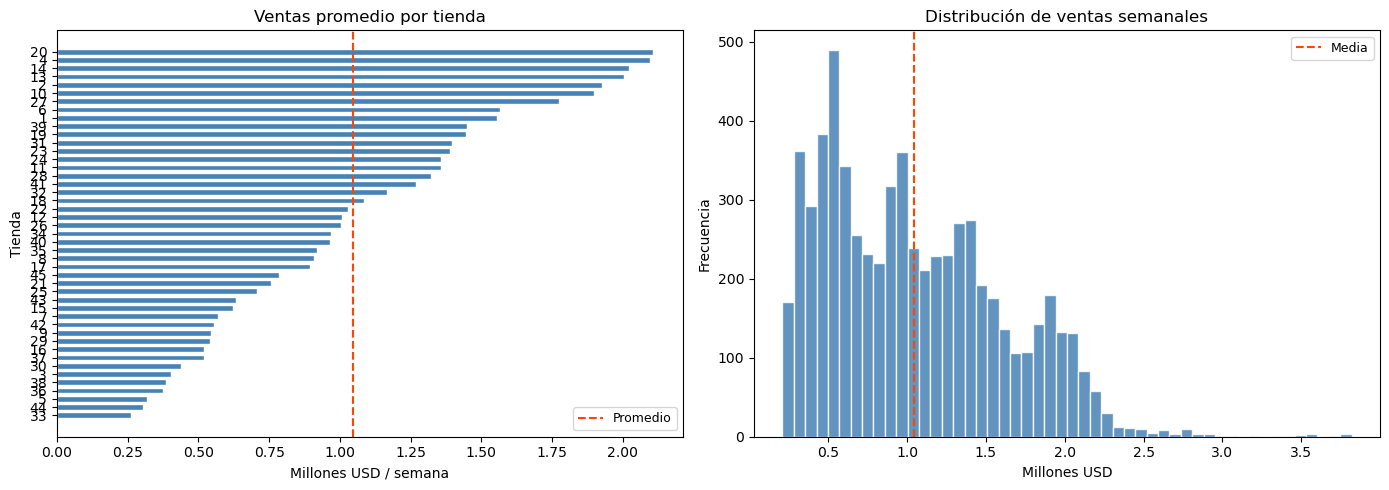

In [3]:
# ============================================================
# 3. ANÁLISIS EXPLORATORIO — ventas por tienda
# ============================================================
# Antes de preprocesar, vemos la distribución de ventas.
# Esto justifica por qué Store debe ser One-Hot y no un número.

ventas_tienda = (dataset.groupby('Store')['Weekly_Sales']
                        .mean()
                        .sort_values(ascending=False))

t_max = ventas_tienda.idxmax()
t_min = ventas_tienda.idxmin()

print(f"Tienda con más ventas: #{t_max} — ${ventas_tienda[t_max]:,.0f}/semana")
print(f"Tienda con menos ventas: #{t_min} — ${ventas_tienda[t_min]:,.0f}/semana")
print(f"Diferencia: {ventas_tienda[t_max]/ventas_tienda[t_min]:.1f}x")
print("\n→ Cada tienda tiene un nivel de ventas muy distinto.")
print("  Por eso tratamos Store como categoría (One-Hot), no como número.")

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ventas_ord = ventas_tienda.sort_values()
axes[0].barh(ventas_ord.index.astype(str), ventas_ord.values / 1e6,
             color='steelblue', edgecolor='white', height=0.7)
axes[0].axvline(ventas_tienda.mean() / 1e6, color='orangered',
                linestyle='--', linewidth=1.5, label='Promedio')
axes[0].set_title('Ventas promedio por tienda', fontsize=12)
axes[0].set_xlabel('Millones USD / semana')
axes[0].set_ylabel('Tienda')
axes[0].legend(fontsize=9)

axes[1].hist(dataset['Weekly_Sales'] / 1e6, bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(dataset['Weekly_Sales'].mean() / 1e6,
                color='orangered', linestyle='--', linewidth=1.5, label='Media')
axes[1].set_title('Distribución de ventas semanales', fontsize=12)
axes[1].set_xlabel('Millones USD')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 4. ONE-HOT ENCODING DE STORE
# ============================================================
# get_dummies convierte la columna Store (45 tiendas) en 44 columnas binarias.
# drop_first=True elimina Store_1 para evitar multicolinealidad
# (si todas las demás son 0, ya sabemos que es Store_1).
#
# Resultado: columnas Store_2, Store_3, ... Store_45
#   Store_5 = 1 → es la tienda 5
#   Store_5 = 0 → no es la tienda 5

print("Columnas ANTES de get_dummies:", dataset.columns.tolist())

dataset = pd.get_dummies(dataset, columns=['Store'], drop_first=True)

print(f"\nColumnas DESPUÉS de get_dummies: {dataset.shape[1]} columnas")
print("Primeras columnas nuevas:",
      [c for c in dataset.columns if 'Store' in str(c)][:8], '...')

Columnas ANTES de get_dummies: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Columnas DESPUÉS de get_dummies: 51 columnas
Primeras columnas nuevas: ['Store_2', 'Store_3', 'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9'] ...


In [5]:
# ============================================================
# 5. SEPARAR X e y — DESCARTAR DATE
# ============================================================
# Descartamos Date porque ya no necesitamos extraer info de ella
# (y el modelo no puede leer texto de fecha directamente).
# Descartamos Weekly_Sales porque es lo que queremos predecir (y).

X = dataset.drop(columns=['Weekly_Sales', 'Date'])
y = dataset['Weekly_Sales']

print(f"Variables de entrada (X): {X.shape[1]} columnas")
print(f"Variable objetivo    (y): Weekly_Sales")
print(f"Registros: {len(X)}")
print("\nColumnas de X:")
print(X.columns.tolist())

Variables de entrada (X): 49 columnas
Variable objetivo    (y): Weekly_Sales
Registros: 6435

Columnas de X:
['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Store_2', 'Store_3', 'Store_4', 'Store_5', 'Store_6', 'Store_7', 'Store_8', 'Store_9', 'Store_10', 'Store_11', 'Store_12', 'Store_13', 'Store_14', 'Store_15', 'Store_16', 'Store_17', 'Store_18', 'Store_19', 'Store_20', 'Store_21', 'Store_22', 'Store_23', 'Store_24', 'Store_25', 'Store_26', 'Store_27', 'Store_28', 'Store_29', 'Store_30', 'Store_31', 'Store_32', 'Store_33', 'Store_34', 'Store_35', 'Store_36', 'Store_37', 'Store_38', 'Store_39', 'Store_40', 'Store_41', 'Store_42', 'Store_43', 'Store_44', 'Store_45']


In [6]:
# ============================================================
# 6. CORRELACIÓN DE PEARSON
# ============================================================
# Revisamos qué variables numéricas principales se correlacionan
# más con las ventas (sin incluir todas las columnas Store_N).

cols_principales = ['Holiday_Flag','Temperature','Fuel_Price',
                    'CPI','Unemployment','Weekly_Sales']
correlacion = (dataset[cols_principales]
               .corr()['Weekly_Sales']
               .drop('Weekly_Sales')
               .sort_values(key=abs, ascending=False))

def nivel(r):
    a = abs(r)
    if a >= 0.4: return 'Moderada'
    elif a >= 0.2: return 'Baja'
    elif a >= 0.05: return 'Muy baja'
    return 'Nula'

tabla = pd.DataFrame({
    'Variable':  correlacion.index,
    'r':         correlacion.round(4).values,
    'Nivel':     [nivel(v) for v in correlacion.values],
    'Dirección': ['↑ sube' if v>0.05 else '↓ baja' if v<-0.05
                  else '→ sin efecto' for v in correlacion.values]
})
print("Correlación variables numéricas vs Weekly_Sales:")
print(tabla.to_string(index=False))
print("\n→ Las numéricas tienen correlación baja.")
print("  El poder predictivo real viene de saber QUÉ tienda es (Store One-Hot).")

Correlación variables numéricas vs Weekly_Sales:
    Variable       r    Nivel    Dirección
Unemployment -0.1062 Muy baja       ↓ baja
         CPI -0.0726 Muy baja       ↓ baja
 Temperature -0.0638 Muy baja       ↓ baja
Holiday_Flag  0.0369     Nula → sin efecto
  Fuel_Price  0.0095     Nula → sin efecto

→ Las numéricas tienen correlación baja.
  El poder predictivo real viene de saber QUÉ tienda es (Store One-Hot).


In [7]:
# ============================================================
# 7. DIVIDIR EN ENTRENAMIENTO Y PRUEBA (80% / 20%)
# ============================================================
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_entrenamiento)} registros (80%)")
print(f"Prueba:         {len(X_prueba)} registros (20%)")

Entrenamiento: 5148 registros (80%)
Prueba:         1287 registros (20%)


In [8]:
# ============================================================
# 8. NORMALIZACIÓN CON StandardScaler
# ============================================================
# StandardScaler transforma cada columna para que tenga:
#   media = 0  y  desviación estándar = 1
#   Fórmula: X_norm = (X - media) / std
#
# Diferencia con Min-Max:
#   Min-Max → rango fijo [0, 1], sensible a outliers
#   StandardScaler → no tiene rango fijo, maneja mejor outliers
#
# IMPORTANTE: fit_transform solo en entrenamiento.
#   fit   → aprende media y std de X_entrenamiento
#   transform → aplica esa misma escala a X_prueba
#   Si hiciéramos fit en prueba, el modelo haría trampa.

normalizador = StandardScaler()

X_entrenamiento_normalizado = normalizador.fit_transform(X_entrenamiento)
X_prueba_normalizado        = normalizador.transform(X_prueba)

print("StandardScaler aplicado.")
print(f"Media de columna 0 después: {X_entrenamiento_normalizado[:,0].mean():.4f} (aprox. 0)")
print(f"Std  de columna 0 después: {X_entrenamiento_normalizado[:,0].std():.4f}  (aprox. 1)")

StandardScaler aplicado.
Media de columna 0 después: -0.0000 (aprox. 0)
Std  de columna 0 después: 1.0000  (aprox. 1)


In [9]:
# ============================================================
# 9. ENTRENAR MODELO — REGRESIÓN LINEAL MÚLTIPLE
# ============================================================
modelo = LinearRegression()
modelo.fit(X_entrenamiento_normalizado, y_entrenamiento)

# Top 10 coeficientes más influyentes
coef_df = pd.DataFrame({
    'Variable':    X.columns,
    'Coeficiente': modelo.coef_
}).reindex(pd.Series(modelo.coef_).abs().sort_values(ascending=False).index)

print(f"Intercepto: {modelo.intercept_:,.2f}")
print("\nTop 10 variables más influyentes:")
print(coef_df.head(10).to_string(index=False))

Intercepto: 1,044,996.41

Top 10 variables más influyentes:
Variable    Coeficiente
 Store_5 -185921.414527
Store_36 -168801.716401
Store_30 -168311.016716
 Store_3 -168062.104087
 Store_9 -153272.098935
Store_37 -151647.927368
Store_16 -149628.363586
Store_44 -147867.146824
Store_33 -142083.128568
 Store_7 -140695.576316


In [10]:
# ============================================================
# 10. MÉTRICAS
# ============================================================
predicciones = modelo.predict(X_prueba_normalizado)

r2  = r2_score(y_prueba, predicciones)
mae = mean_absolute_error(y_prueba, predicciones)
mse = mean_squared_error(y_prueba, predicciones)

print("================================================")
print("MÉTRICAS — Regresión Lineal Múltiple")
print("================================================")
print(f"R²:        {r2:.4f}  → explica el {r2*100:.1f}% de la variación")
print(f"MAE:       ${mae:>12,.0f} USD en promedio")
print(f"MSE:       {mse:,.0f}")
print(f"\n→ Al tratar Store como categoría (One-Hot) el modelo")
print(f"  aprende el nivel de ventas propio de cada tienda,")
print(f"  lo que explica el R² alto.")

MÉTRICAS — Regresión Lineal Múltiple
R²:        0.9208  → explica el 92.1% de la variación
MAE:       $      91,044 USD en promedio
MSE:       25,498,969,757

→ Al tratar Store como categoría (One-Hot) el modelo
  aprende el nivel de ventas propio de cada tienda,
  lo que explica el R² alto.


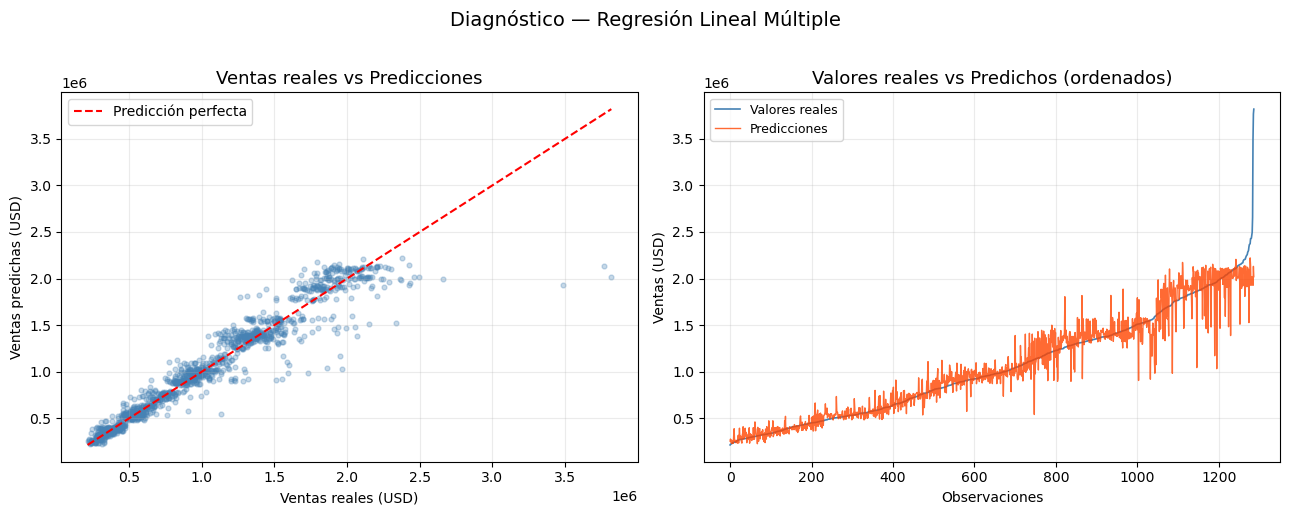

Residuos — desv. estándar: $159,627 USD
Residuos — peor error:     $1,799,223 USD

→ Si la línea roja sigue de cerca la azul → buen ajuste.
→ Picos donde se separan = casos que el modelo lineal no captura del todo.


In [11]:
# ============================================================
# 11. GRÁFICAS DE DIAGNÓSTICO
# ============================================================

residuos = y_prueba.values - predicciones

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: real vs predicción
axes[0].scatter(y_prueba, predicciones, alpha=0.3, s=12, color='steelblue')
lim = [y_prueba.min(), y_prueba.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title('Ventas reales vs Predicciones', fontsize=13)
axes[0].set_xlabel('Ventas reales (USD)')
axes[0].set_ylabel('Ventas predichas (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# Línea: real vs predicción ordenadas
idx = np.argsort(y_prueba.values)
axes[1].plot(y_prueba.values[idx], color='steelblue',
             linewidth=1.2, label='Valores reales')
axes[1].plot(predicciones[idx],    color='orangered',
             linewidth=1,   label='Predicciones', alpha=0.8)
axes[1].set_title('Valores reales vs Predichos (ordenados)', fontsize=13)
axes[1].set_xlabel('Observaciones')
axes[1].set_ylabel('Ventas (USD)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.25)

plt.suptitle('Diagnóstico — Regresión Lineal Múltiple', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Residuos — desv. estándar: ${residuos.std():,.0f} USD")
print(f"Residuos — peor error:     ${np.abs(residuos).max():,.0f} USD")
print("\n→ Si la línea roja sigue de cerca la azul → buen ajuste.")
print("→ Picos donde se separan = casos que el modelo lineal no captura del todo.")

In [12]:
# ============================================================
# 12. PREDICCIÓN — nueva semana
# ============================================================
# Para predecir hay que construir el DataFrame con TODAS las columnas
# que usó el modelo (incluidas las columnas Store_N).
# reindex(columns=X.columns, fill_value=0) rellena con 0 las tiendas
# que no especificamos — solo ponemos 1 en la tienda que queremos.

nueva_semana = pd.DataFrame({
    'Temperature':  [25],
    'Fuel_Price':   [3.2],
    'CPI':          [220],
    'Unemployment': [7],
    'Holiday_Flag': [1],
    # Indicar qué tienda es — el resto queda en 0
    'Store_5':      [1],    # tienda 5
})

# Ajustar columnas al mismo orden que X
nueva_semana = nueva_semana.reindex(columns=X.columns, fill_value=0)

# Normalizar con el mismo scaler entrenado
nueva_semana_normalizada = normalizador.transform(nueva_semana)

# Predecir
prediccion = modelo.predict(nueva_semana_normalizada)

print("VENTAS PREDICHAS — Tienda 5, semana de feriado:")
print(f"${prediccion[0]:,.2f} USD")

VENTAS PREDICHAS — Tienda 5, semana de feriado:
$418,844.48 USD


---
## 📌 Conclusión

| Métrica | Resultado |
|---|---|
| **R²** | ~0.92 — explica el 92% de la variación |
| **MAE** | ~$91,000 USD de error promedio |

**La clave del buen resultado:** tratar `Store` como **One-Hot** en vez de número.  
Cada tienda tiene su propio nivel de ventas base, y el modelo lo aprende por separado.

**¿Hay espacio para mejorar?**  
Sí — la Regresión Polinomial puede capturar relaciones no lineales entre  
las variables (picos estacionales, efectos combinados) y reducir un poco más el error.